## Question 14 — Auto Dataset

The exercise asks us to predict whether a car has high or low gas mileage using the Auto dataset. The ISLP Auto dataset contains 392 vehicles and variables such as mpg, cylinders, displacement, horsepower, weight, acceleration, year and origin.

In [3]:
pip install ISLP

  Using cached islp-0.4.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pygam-0.12.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached torch-2.13.0-cp312-cp312-win_amd64.whl.metadata (39 kB)
  Using cached pytorch_lightning-2.6.5-py3-none-any.whl.metadata (21 kB)
  Using cached torchmetrics-1.9.0-py3-none-any.whl.metadata (23 kB)
  Using cached autograd_gamma-0.5.0-py3-none-any.whl
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached progressbar2-4.6.0-py3-none-any.whl.metadata (10 kB)
Using cached islp-0.4.1-py3-none-any.whl (16.6 MB)
Using cached lifelines-0.30.3-py3-none-any.whl (409 kB)
Using cached pygam-0.12.0-py3-none-any.whl (84 kB)
Using cached pytorch_lightning-2.6.5-py3-none-any.whl (852 kB)
Using cached torch-2.13.0-cp312-cp312-win_amd64.whl (122.1 MB)
Using cached torchmetrics-1.9.0-py3-none-any.whl (983 kB)
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached 

In [1]:
import numpy as np
import pandas as pd

from ISLP import load_data

Auto = load_data('Auto')

median_mpg = Auto['mpg'].median()

Auto['mpg01'] = (Auto['mpg'] > median_mpg).astype(int)

print("Median MPG:", median_mpg)
print(Auto.head())

Median MPG: 22.75
                            mpg  cylinders  displacement  horsepower  weight  \
name                                                                           
chevrolet chevelle malibu  18.0          8         307.0         130    3504   
buick skylark 320          15.0          8         350.0         165    3693   
plymouth satellite         18.0          8         318.0         150    3436   
amc rebel sst              16.0          8         304.0         150    3433   
ford torino                17.0          8         302.0         140    3449   

                           acceleration  year  origin  mpg01  
name                                                          
chevrolet chevelle malibu          12.0    70       1      0  
buick skylark 320                  11.5    70       1      0  
plymouth satellite                 11.0    70       1      0  
amc rebel sst                      12.0    70       1      0  
ford torino                        10.5    

## (b) Explore the data graphically

We want to determine which variables are most useful for predicting mpg01.

In [3]:
print(
    Auto[
        ['mpg01', 'cylinders', 'displacement',
         'horsepower', 'weight', 'acceleration',
         'year', 'origin']
    ].corr()['mpg01'].sort_values()
)

cylinders      -0.759194
weight         -0.757757
displacement   -0.753477
horsepower     -0.667053
acceleration    0.346822
year            0.429904
origin          0.513698
mpg01           1.000000
Name: mpg01, dtype: float64


## BOXPLOTS

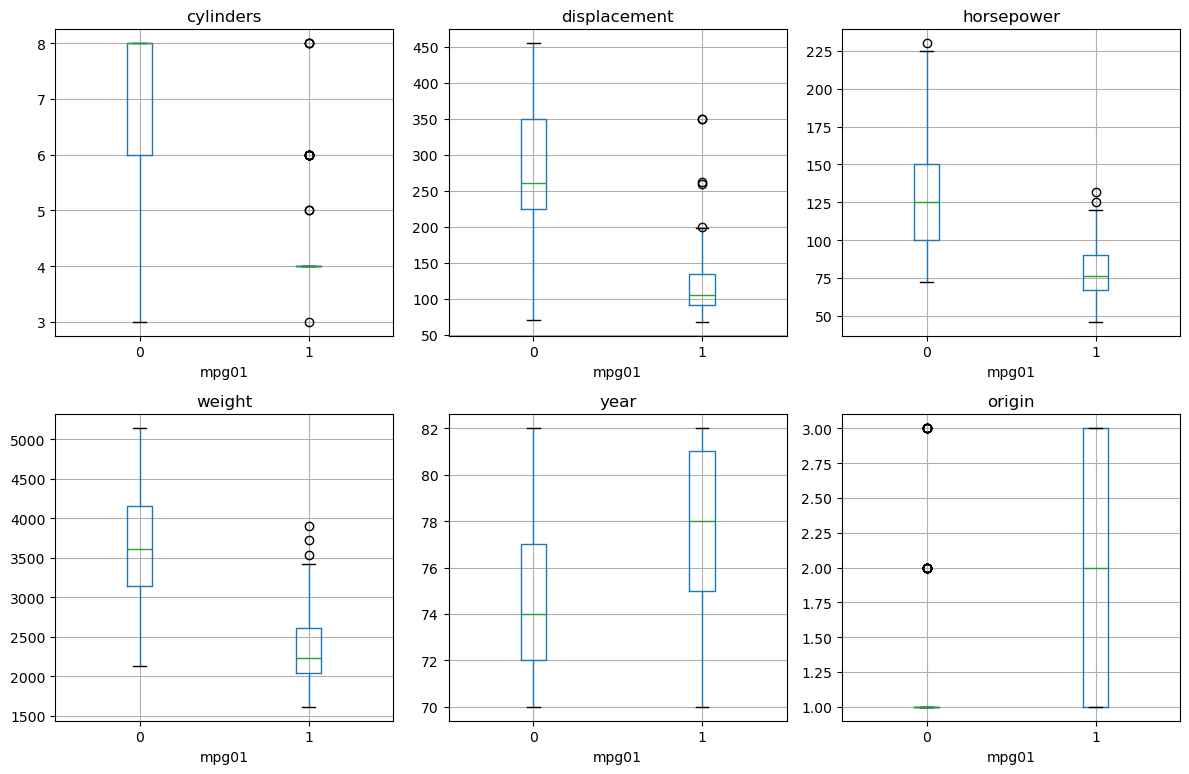

In [5]:
import matplotlib.pyplot as plt

variables = [
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'year',
    'origin'
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, var in zip(axes.ravel(), variables):
    Auto.boxplot(column=var, by='mpg01', ax=ax)
    ax.set_title(var)
    ax.set_xlabel('mpg01')

plt.suptitle('')
plt.tight_layout()
plt.show()

## (c) Split into training and test sets
We'll use 50% training and 50% testing.

In [7]:
from sklearn.model_selection import train_test_split

features = [
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'year'
]

X = Auto[features]
y = Auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=1,
    stratify=y
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 196
Test observations: 196


## d) LDA

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

lda_pred = lda.predict(X_test)

lda_error = 1 - accuracy_score(y_test, lda_pred)

print("LDA test error:", lda_error)

LDA test error: 0.09693877551020413


## (e) QDA

In [11]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train, y_train)

qda_pred = qda.predict(X_test)

qda_error = 1 - accuracy_score(y_test, qda_pred)

print("QDA test error:", qda_error)

QDA test error: 0.11734693877551017


## (f) Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=5000)

logit.fit(X_train, y_train)

logit_pred = logit.predict(X_test)

logit_error = 1 - accuracy_score(y_test, logit_pred)

print("Logistic regression test error:", logit_error)

Logistic regression test error: 0.10204081632653061


## (g) Naive Bayes

In [15]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_error = 1 - accuracy_score(y_test, nb_pred)

print("Naive Bayes test error:", nb_error)

Naive Bayes test error: 0.11224489795918369


## (h) KNN

For KNN, scaling is important because the variables have very different units.
For example:
horsepower ≈ 100
weight ≈ 3,000
year ≈ 70

Without scaling, weight would dominate the distance calculation.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

for K in [1, 3, 5, 7, 9, 11]:

    knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=K)
    )

    knn.fit(X_train, y_train)

    knn_pred = knn.predict(X_test)

    error = 1 - accuracy_score(y_test, knn_pred)

    print("K =", K, "Test error =", error)

K = 1 Test error = 0.07653061224489799
K = 3 Test error = 0.08163265306122447
K = 5 Test error = 0.09183673469387754
K = 7 Test error = 0.10204081632653061
K = 9 Test error = 0.11224489795918369
K = 11 Test error = 0.11224489795918369


## Question 16 — Boston Dataset

In [19]:
## lOAD DATA
from ISLP import load_data

Boston = load_data('Boston')

print(Boston.head())
print(Boston.shape)

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

   lstat  medv  
0   4.98  24.0  
1   9.14  21.6  
2   4.03  34.7  
3   2.94  33.4  
4   5.33  36.2  
(506, 13)


In [21]:
##Create the response variable

median_crim = Boston['crim'].median()

Boston['crim01'] = (
    Boston['crim'] > median_crim
).astype(int)

print("Median crime rate:", median_crim)
print(Boston[['crim', 'crim01']].head())

Median crime rate: 0.25651
      crim  crim01
0  0.00632       0
1  0.02731       0
2  0.02729       0
3  0.03237       0
4  0.06905       0


In [23]:
## Explore associations

variables = [
    'zn', 'indus', 'chas', 'nox', 'rm',
    'age', 'dis', 'rad', 'tax',
    'ptratio', 'lstat', 'medv'
]

correlations = Boston[
    variables + ['crim01']
].corr()['crim01'].sort_values()

print(correlations)

dis       -0.616342
zn        -0.436151
medv      -0.263017
rm        -0.156372
chas       0.070097
ptratio    0.253568
lstat      0.453263
indus      0.603260
tax        0.608741
age        0.613940
rad        0.619786
nox        0.723235
crim01     1.000000
Name: crim01, dtype: float64


In [25]:
##Split the data

from sklearn.model_selection import train_test_split

features = [
    'nox',
    'rad',
    'age',
    'tax',
    'indus',
    'dis'
]

X = Boston[features]
y = Boston['crim01']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=1,
    stratify=y
)

In [27]:
##Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

logit = LogisticRegression(max_iter=5000)

logit.fit(X_train, y_train)

pred = logit.predict(X_test)

error = 1 - accuracy_score(y_test, pred)

print("Logistic regression error:", error)

Logistic regression error: 0.1541501976284585


In [29]:
## LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

pred = lda.predict(X_test)

error = 1 - accuracy_score(y_test, pred)

print("LDA error:", error)

LDA error: 0.1620553359683794


In [31]:
##Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

pred = nb.predict(X_test)

error = 1 - accuracy_score(y_test, pred)

print("Naive Bayes error:", error)

Naive Bayes error: 0.1699604743083004


In [33]:
##KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

for K in [1, 3, 5, 10]:

    knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=K)
    )

    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    error = 1 - accuracy_score(y_test, pred)

    print("K =", K, "Error =", error)

K = 1 Error = 0.06719367588932801
K = 3 Error = 0.07905138339920947
K = 5 Error = 0.07509881422924902
K = 10 Error = 0.08300395256916993
